### ![alt text](https://nexteducacion.com/wp-content/uploads/2020/02/cropped-next-educaci%C3%B3n.png.webp "nextEDUCACION")
### Máster en Big Data y Business Intelligence.

### Obtencion de Datos para el TFM.
**Autores**
- David Mejía Cascante
- Daniel Vargas Salazar
- Juan Luis Chávez Mejía
- María Cubero Sandoval
- Melany Jiménez Nin

### Asignatura 5.Fuentes y Obtención de Datos.
### **Profesora: Xisca Sorell**
### Fecha: 31 de Enero del 2026.

## 1. Selección del dataset

Se ha elegido la API de ***Real-Time Glassdoor Data*** en RapidAPI.

**Dataset:** https://rapidapi.com/letscrape-6bRBa3QguO5/api/real-time-glassdoor-data

## 2. Objetivos.
El síndrome de burnout representa uno de los principales desafíos actuales en el ámbito de la salud mental laboral, debido a las crecientes exigencias de los entornos de trabajo modernos, la presión por la productividad y la dificultad para mantener un equilibrio entre la vida personal y profesional. Este fenómeno, reconocido por la Organización Mundial de la Salud como un riesgo ocupacional, se desarrolla de manera progresiva y suele ser identificado en etapas avanzadas, cuando sus efectos sobre el bienestar de las personas y el desempeño organizacional ya son significativos. Por ello, la detección temprana del riesgo de burnout se ha convertido en una necesidad prioritaria tanto para las organizaciones como para los sistemas de salud.

En este contexto, las tecnologías de Big Data e Inteligencia Artificial ofrecen un enfoque innovador para la identificación temprana de patrones asociados al riesgo de burnout, mediante el análisis de grandes volúmenes de datos provenientes de diversas fuentes. A partir de esta premisa surge este proyecto, el cual tiene como objetivo explorar la viabilidad de un sistema basado en datos que permita identificar señales tempranas de riesgo utilizando información obtenida a través de APIs y otras fuentes de datos.
El proyecto se centra en la obtención, preparación y documentación de datos accesibles, empleando herramientas de programación en Python dentro del entorno Google Colab, con el fin de garantizar un proceso automatizado y reproducible. No obstante, durante el desarrollo del trabajo se identificaron limitaciones relevantes en los datos obtenidos, como un alto nivel de agregación, escasa granularidad temporal y ausencia de variables directamente relacionadas con indicadores psicológicos del burnout. Estas restricciones condicionaron el alcance del sistema propuesto y evidenciaron las dificultades existentes en el uso de datos abiertos para proyectos de detección temprana en el ámbito de la salud mental.

En consecuencia, el objetivo del proyecto es analizar y documentar de manera crítica el proceso de obtención de datos mediante diferentes fuentes de datos y evaluar su adecuación para el diseño conceptual de un sistema de detección temprana de riesgo de burnout, aportando una reflexión metodológica sobre las oportunidades y limitaciones del uso de Big Data e Inteligencia Artificial en este contexto.




## 3. Limpieza y preparación de los datos

### 3.1 Preparacion del entorno y librerias necesarias.

In [ ]:
#Hacemos nuestros imports
import pandas as pd
import requests
import time
import re
from datetime import datetime
import matplotlib.pyplot as plt

In [ ]:
#keys necesarios para conectar con la API
#restriccion de 100 queries por mes

#url para buscar el codigo de la compañia
URL1 = "https://real-time-glassdoor-data.p.rapidapi.com/company-search"

#usaremos el "company_id:9079" que parece ser los headquaters de Google.
URL2 = "https://real-time-glassdoor-data.p.rapidapi.com/company-reviews"

HEADERS = {
	"x-rapidapi-key": "18961711b4mshb03fc723f71d161p11f4e3jsn9c90bfc62775",
	"x-rapidapi-host": "real-time-glassdoor-data.p.rapidapi.com"
}
COMPANIES = [
		['DELOITTE',2763],
		['MICROSOFT',1651],
		['INTEL',1519],
		['CISCO',1425],
		['APPLE',1138],
		['NORTHROP_GRUMMAN',488],
		['LOCKHEED_MARTIN',404],
		['IBM',354],
		['SAP',10471],
		['TP',9779],
		['GOOGLE',9079],
		['ACCENTURE',4138],
		['CAPGEMINI',3803],
		['FIDELITY_INVESTMENTS',2786]
]

BASE_PARAMS_2 = {
    "company_id": "9079",
    "sort": "MOST_RECENT",
    "language": "en",
    "only_current_employees": "false",
    "extended_rating_data": "false",
    "domain": "www.glassdoor.com"
}

BASE_PARAMS = {
    "sort": "MOST_RECENT",
    "language": "en",
    "only_current_employees": "false",
    "extended_rating_data": "false",
    "domain": "www.glassdoor.com"
}
KEY_WORDS = ['burnout','exhaustion','depersonalization','reduced personal accomplishment','negative feedback','stress','excessive workload','work overload','role overload','job demands–resources model','customer-related stressors','emotional labor','difficult client','workplace incivility','abuse','psychosocial','job strain','effort–reward imbalance','employee well-being','work-related mental health','burnout','toxic','miserable','hell','bad']

In [ ]:
#Este metodo buscara los reviews de compañias en un maximo de las primeras 10 paginas. Esto debido a la restriccion de la API en la cantidad de llamados.

def fetch_recursive_reviews(company_id, start_page=1, max_pages=10):
    all_reviews = []
    page = start_page

    while page <= max_pages:
        params = {"company_id": str(company_id)} | BASE_PARAMS | {"page": str(page)}
        response2 = requests.get(URL2, headers=HEADERS, params=params)

        if response2.status_code != 200:
          print('Response code: ',response2.status_code)
          break

        tmp2 = response2.json()
        reviews = tmp2.get('data')
        if not reviews:
            break
        all_reviews.extend(reviews['reviews'])
        page += 1

        dft = pd.DataFrame(all_reviews)
        dft.to_csv(f"{str(COMPANIES[page][0])}_reviews.csv", index=False)
        time.sleep(1)

    return pd.DataFrame(all_reviews)

In [ ]:
#Este metodo buscara en diferentes compañias los reviews.
def fetch_company_reviews(start_company=0, max_company=10):
    all_reviews = []
    page = start_company
    while page <= max_company:
      fetch_recursive_reviews(COMPANIES[page][1], start_page=1, max_pages=10)
      page += 1
      time.sleep(1)
    return pd.DataFrame(all_reviews)

fetch_company_reviews(start_company=0, max_company=10)

Response code:  429


""


In [ ]:
#Ahora cargaremos en dataframes los diferentes archviso csv generados con los datos.
def load_company_data():
  df = pd.DataFrame()
  for company in COMPANIES:
    filename = f"{str(company[0])}_reviews.csv"
    try:
      df_tmp = pd.read_csv(filename)
      df_tmp.insert(loc=0, column='company', value=str(company[0]))
      df_tmp.insert(loc=1, column='company_id', value=str(company[1]))
    except FileNotFoundError:
      continue
    df = pd.concat([df, df_tmp], ignore_index=True)
  return df

In [ ]:
df = load_company_data()

In [ ]:
print(df.keys())

Index(['company', 'company_id', 'review_id', 'summary', 'pros', 'cons',
       'rating', 'review_link', 'job_title', 'review_datetime',
       'employment_status', 'is_current_employee', 'years_of_employment',
       'location', 'helpful_count', 'not_helpful_count',
       'business_outlook_rating', 'career_opportunities_rating', 'ceo_rating',
       'compensation_and_benefits_rating', 'culture_and_values_rating',
       'diversity_and_inclusion_rating', 'recommend_to_friend_rating',
       'senior_management_rating', 'work_life_balance_rating', 'language',
       'advice_to_management'],
      dtype='object')


In [ ]:
df1 = df.drop(columns=['diversity_and_inclusion_rating','culture_and_values_rating','review_link','years_of_employment','not_helpful_count','helpful_count','business_outlook_rating','ceo_rating'])

In [ ]:
print(df1.keys())

Index(['company', 'company_id', 'review_id', 'summary', 'pros', 'cons',
       'rating', 'job_title', 'review_datetime', 'employment_status',
       'is_current_employee', 'location', 'career_opportunities_rating',
       'compensation_and_benefits_rating', 'recommend_to_friend_rating',
       'senior_management_rating', 'work_life_balance_rating', 'language',
       'advice_to_management'],
      dtype='object')


### 3.2 Revisión de tipos de datos.

In [ ]:
df1['review_datetime'] = pd.to_datetime(df1['review_datetime'], errors='coerce')

df1['company_id'] = pd.to_numeric(df1['company_id'], errors='coerce').astype('Int64')
df1['career_opportunities_rating'] = pd.to_numeric(df1['career_opportunities_rating'], errors='coerce').astype('Int64')
df1['compensation_and_benefits_rating'] = pd.to_numeric(df1['compensation_and_benefits_rating'], errors='coerce').astype('Int64')
df1['senior_management_rating'] = pd.to_numeric(df1['senior_management_rating'], errors='coerce').astype('Int64')
df1['work_life_balance_rating'] = pd.to_numeric(df1['work_life_balance_rating'], errors='coerce').astype('Int64')
df1['rating'] = pd.to_numeric(df1['rating'], errors='coerce').astype('Int64')

df1['is_current_employee'] = df1['is_current_employee'].astype('category')
df1['employment_status'] = df1['employment_status'].astype('category')
df1['job_title'] = df1['job_title'].astype('category')
df1['location'] = df1['location'].astype('category')
df1['language'] = df1['language'].astype('category')
df1['recommend_to_friend_rating'] = df1['recommend_to_friend_rating'].astype('category')

df1['review_id'] = df1['review_id'].fillna('n/a').astype('string')
df1['summary'] = df1['summary'].fillna('n/a').astype('string')
df1['company'] = df1['company'].fillna('n/a').astype('string')
df1['pros'] = df1['pros'].fillna('n/a').astype('string')
df1['cons'] = df1['cons'].fillna('n/a').astype('string')
df1['advice_to_management'] = df1['advice_to_management'].fillna('n/a').astype('string')

In [ ]:
#Valores nulos
df1.isna().sum().sort_values(ascending=False)

,0
work_life_balance_rating,181
recommend_to_friend_rating,181
senior_management_rating,172
career_opportunities_rating,165
compensation_and_benefits_rating,161
location,75
job_title,44
employment_status,7
review_id,0
company,0


In [ ]:
print("Valores duplicados en el dataset: ", df1.duplicated().sum())

Valores duplicados en el dataset:  28


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   company                           670 non-null    string             
 1   company_id                        670 non-null    Int64              
 2   review_id                         670 non-null    string             
 3   summary                           670 non-null    string             
 4   pros                              670 non-null    string             
 5   cons                              670 non-null    string             
 6   rating                            670 non-null    Int64              
 7   job_title                         626 non-null    category           
 8   review_datetime                   670 non-null    datetime64[ns, UTC]
 9   employment_status                 663 non-null    category       

In [ ]:
pattern = re.compile(
    r'\b(?:' + '|'.join(map(re.escape, KEY_WORDS)) + r')\b',
    flags=re.IGNORECASE
)

df1['keyword_count'] = 0 # Initialize the column with zeros
df1['keyword_count'] += df1['summary'].str.count(pattern).fillna(0).astype(int)
df1['keyword_count'] += df1['pros'].str.count(pattern).fillna(0).astype(int)
df1['keyword_count'] += df1['cons'].str.count(pattern).fillna(0).astype(int)
df1['keyword_count'] += df1['advice_to_management'].str.count(pattern).fillna(0).astype(int)


53


In [ ]:
df1.to_csv('reviews.csv', index=False)

### 3.3 Valores atipicos.

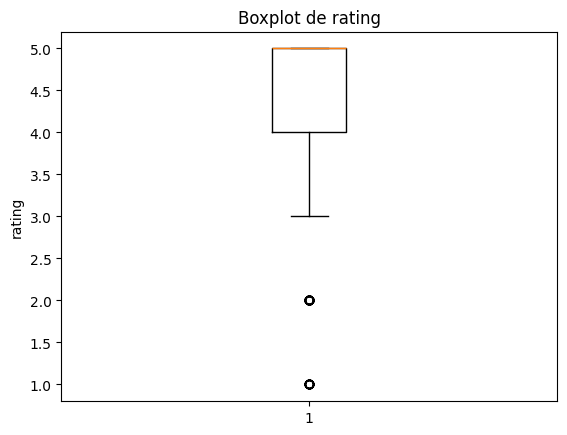

In [ ]:
# Eliminar nulos
ratings = df1["rating"].dropna()

# Cálculo de IQR
Q1 = ratings.quantile(0.25)
Q3 = ratings.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Extraer outliers
outliers = df1[(df1["rating"] < lower_bound) | (df1["rating"] > upper_bound)]

# Boxplot
plt.figure()
plt.boxplot(ratings)
plt.title("Boxplot de rating")
plt.ylabel("rating")
plt.show()

# Mostrar límites y outliers
#print("Límite inferior:", lower_bound)
#print("Límite superior:", upper_bound)
#print("Outliers:")
#print(outliers)

### 3.4 Feature engineering.

In [ ]:
from numpy import datetime64

def clasificar_variable(serie):
    tipo = serie.dtype

    # Si es un número entero → numérica discreta
    if tipo == "Int64":
        return "Numérica discreta"

    # Si es número con decimales → numérica continua
    if tipo == "Float64":
        return "Numérica continua"

    #
    if tipo == "datetime64[ns]":
        return "Categórica ordinal (fecha)"

    # Si es texto (object) → categórica
    if tipo == "object" or tipo == "category":
        # contamos cuántas categorías diferentes tiene
        categorias = serie.nunique()

        # si solo hay dos categorías → binaria
        if categorias == 2:
            return "Categórica binaria"

        # si hay más de dos → nominal
        else:
            return "Categórica nominal"

    return "Otro tipo"

In [ ]:
print("CLASIFICACIÓN AUTOMÁTICA")

for col in df1.columns:
    tipo_estadistico = clasificar_variable(df1[col])
    print(f"{col}: {tipo_estadistico}")

CLASIFICACIÓN AUTOMÁTICA
company: Otro tipo
company_id: Numérica discreta
review_id: Otro tipo
summary: Otro tipo
pros: Otro tipo
cons: Otro tipo
rating: Numérica discreta
job_title: Categórica nominal
review_datetime: Otro tipo
employment_status: Categórica nominal
is_current_employee: Categórica binaria
location: Categórica nominal
career_opportunities_rating: Numérica discreta
compensation_and_benefits_rating: Numérica discreta
recommend_to_friend_rating: Categórica binaria
senior_management_rating: Numérica discreta
work_life_balance_rating: Numérica discreta
language: Categórica nominal
advice_to_management: Otro tipo
keyword_count: Otro tipo


## 4. Analisis exploratorio de datos (EDA).

### 4.1 Análisis univariante:

In [ ]:
#Empresas distintas dentro del reporte.
print(df1['company'].nunique())

13


In [ ]:
#Cantidad de reportes.
print(df1['review_id'].nunique())

142


In [ ]:
#Promedio del rating
print(df['rating'].mean())

4.2253731343283585


In [ ]:
#Distintos Job Titles.
print(df1['job_title'].nunique())

92


In [ ]:
#Distintos estados de empleamiento.
print(df1['employment_status'].nunique())

6


In [ ]:
#Cantidad de trabajados activos.
print(df1['is_current_employee'].value_counts())

is_current_employee
True     525
False    145
Name: count, dtype: int64


In [ ]:
#promedio de oportunidades laborares.
print(df['career_opportunities_rating'].mean())

4.144554455445545


In [ ]:
#promedio de beneficios y compensacion.
print(df['compensation_and_benefits_rating'].mean())

4.292730844793713


In [ ]:
#Cantidad que recomendarian la empresa a un amigo.
print(df1['recommend_to_friend_rating'].value_counts())

recommend_to_friend_rating
POSITIVE    435
NEGATIVE     54
Name: count, dtype: int64


In [ ]:
#promedio del balance vida-trabajo
print(df['work_life_balance_rating'].mean())

3.9959100204498976


In [ ]:
#cantidad de keywords encontrados en todos los datos.
print(df1['keyword_count'].sum())

53


### 4.2 Análisis Bivariante

In [ ]:
#cantidad de comentarios por empresa.
print(df1.groupby('company')['review_id'].count())

company
ACCENTURE               100
APPLE                    30
CAPGEMINI                30
CISCO                    20
DELOITTE                 50
FIDELITY_INVESTMENTS     40
GOOGLE                   90
IBM                      60
INTEL                    10
LOCKHEED_MARTIN          50
NORTHROP_GRUMMAN         40
SAP                      70
TP                       80
Name: review_id, dtype: int64


In [ ]:
#promedio del rating por empresa.
print(df1.groupby('company')['rating'].mean())

company
ACCENTURE                   4.09
APPLE                   4.266667
CAPGEMINI               4.366667
CISCO                        4.5
DELOITTE                    4.38
FIDELITY_INVESTMENTS       4.475
GOOGLE                  4.155556
IBM                         4.15
INTEL                        4.4
LOCKHEED_MARTIN             3.98
NORTHROP_GRUMMAN             4.1
SAP                     4.271429
TP                         4.325
Name: rating, dtype: Float64


In [ ]:
#tipos de empleados por empresa.
print(df1.groupby('company')['employment_status'].value_counts())

company    employment_status
ACCENTURE  REGULAR              92
           CONTRACT              3
           PART_TIME             3
           TEMPORARY             1
           FREELANCE             0
                                ..
TP         CONTRACT              3
           PART_TIME             2
           TEMPORARY             1
           FREELANCE             0
           INTERN                0
Name: count, Length: 78, dtype: int64


In [ ]:
#Situacion laboral por empresa.
print(df1.groupby('company')['is_current_employee'].value_counts())

company               is_current_employee
ACCENTURE             True                   81
                      False                  19
APPLE                 True                   27
                      False                   3
CAPGEMINI             True                   16
                      False                  14
CISCO                 True                   19
                      False                   1
DELOITTE              True                   26
                      False                  24
FIDELITY_INVESTMENTS  False                  20
                      True                   20
GOOGLE                True                   75
                      False                  15
IBM                   True                   50
                      False                  10
INTEL                 True                    9
                      False                   1
LOCKHEED_MARTIN       True                   40
                      False                  1

In [ ]:
#oportunidades laborales por empresa.
print(df1.groupby('company')['career_opportunities_rating'].mean())

company
ACCENTURE               4.144578
APPLE                   4.291667
CAPGEMINI               3.785714
CISCO                   4.166667
DELOITTE                3.958333
FIDELITY_INVESTMENTS         4.0
GOOGLE                  4.173333
IBM                      4.12766
INTEL                   4.222222
LOCKHEED_MARTIN         3.891892
NORTHROP_GRUMMAN        3.967742
SAP                     4.280702
TP                      4.348485
Name: career_opportunities_rating, dtype: Float64


In [ ]:
#compensacion y beneficios por empresa.
print(df1.groupby('company')['compensation_and_benefits_rating'].mean())

company
ACCENTURE               4.192771
APPLE                       4.32
CAPGEMINI               4.428571
CISCO                   4.263158
DELOITTE                4.434783
FIDELITY_INVESTMENTS    4.421053
GOOGLE                       4.2
IBM                       4.3125
INTEL                   4.111111
LOCKHEED_MARTIN         4.131579
NORTHROP_GRUMMAN          4.1875
SAP                     4.431034
TP                      4.439394
Name: compensation_and_benefits_rating, dtype: Float64


In [ ]:
#recomendaciones a amigos por empresa.
print(df1.groupby('company')['recommend_to_friend_rating'].value_counts())

company               recommend_to_friend_rating
ACCENTURE             POSITIVE                      67
                      NEGATIVE                      13
APPLE                 POSITIVE                      23
                      NEGATIVE                       1
CAPGEMINI             POSITIVE                      14
                      NEGATIVE                       1
CISCO                 POSITIVE                      17
                      NEGATIVE                       1
DELOITTE              POSITIVE                      22
                      NEGATIVE                       2
FIDELITY_INVESTMENTS  POSITIVE                      18
                      NEGATIVE                       1
GOOGLE                POSITIVE                      61
                      NEGATIVE                      11
IBM                   POSITIVE                      40
                      NEGATIVE                       5
INTEL                 POSITIVE                       8
                

In [ ]:
#balance de trabajo y vida personal por empresa.
print(df1.groupby('company')['work_life_balance_rating'].mean())

company
ACCENTURE               3.987342
APPLE                       4.12
CAPGEMINI               3.692308
CISCO                        4.0
DELOITTE                3.681818
FIDELITY_INVESTMENTS    3.722222
GOOGLE                  3.957746
IBM                     4.042553
INTEL                   4.111111
LOCKHEED_MARTIN         3.815789
NORTHROP_GRUMMAN         3.96875
SAP                     4.166667
TP                      4.177419
Name: work_life_balance_rating, dtype: Float64


In [ ]:
#cantidad de keywords encontrados por empresa.
print(df1.groupby('company')['keyword_count'].sum())

company
ACCENTURE               5
APPLE                   2
CAPGEMINI               4
CISCO                   2
DELOITTE                6
FIDELITY_INVESTMENTS    5
GOOGLE                  5
IBM                     5
INTEL                   2
LOCKHEED_MARTIN         5
NORTHROP_GRUMMAN        2
SAP                     5
TP                      5
Name: keyword_count, dtype: int64


## 6. Conclusiones

Limitaciones encontradas con el uso de los API ya que estos tienen un límite de usos por mes. Si se excede ese número la API no retorna ningún resultado si no se paga una suscripción.
Para el desarrollo del TFM debemos considerar hacer uso de web scrapping en la misma fuente de datos que la API para evitar incurrir en gastos de suscripción y tener un mayor gama de datos.
Debido a la restriccion del API, se hizo un llamado recurrente para extraer la mayor cantidad de datos y estos fueron exportados a archivos csv.
Para futuros avances del TFM, se puede considerar usar keywords del analisis de los datos de kaggle para buscarlos en los feedback de los colaboradores.

El proyecto permitió evaluar el uso de APIs para la obtención de datos. Aunque el proceso de extracción y análisis exploratorio fue técnicamente correcto, los datos obtenidos presentaron limitaciones relevantes en granularidad y pertinencia para la detección temprana del burnout. No obstante, el trabajo aporta valor metodológico al documentar el proceso y evidenciar los retos reales del uso de datos abiertos en proyectos de salud mental.
A través del uso de APIs y fuentes adicionales de datos y del análisis exploratorio de datos, se constató que la disponibilidad de datos abiertos no siempre es suficiente para desarrollar sistemas predictivos complejos como la detección temprana del burnout. Las limitaciones identificadas condicionaron el alcance del proyecto, resaltando la importancia de evaluar la calidad y adecuación de los datos desde las primeras etapas del análisis.
El desarrollo del proyecto permitió aplicar de forma práctica los conceptos de obtención, extracción y análisis exploratorio de datos. Si bien la información obtenida no permitió implementar un sistema completo de detección temprana de burnout, el proyecto cumplió su objetivo académico al ofrecer una visión crítica sobre el uso de APIs y datos abiertos en este tipo de problemáticas.
En conclusión, el proyecto demostró que, aunque el uso de APIs facilita la obtención de datos, la calidad y especificidad de la información son factores determinantes para el desarrollo de sistemas de detección temprana del burnout.

